Cognitive Decline Risk Prediction

Data and statistical analysis

Step 1: Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


Step 2: Load the dataset and initial exploration

In [2]:
# data = pd.read_csv("datasets/enhanced_anxiety_dataset.csv")
data = pd.read_csv("datasets/family_anxiety_14_dataset.csv")

# basic dataset info

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nColumn Names:")
print(data.columns.tolist())
print("\nData Types:")
print(data.dtypes)


Dataset shape: (11000, 19)

First 5 rows:
   Age  Gender Occupation  Sleep Hours  Physical Activity (hrs/week)  \
0   58    Male      Nurse          6.2                           1.3   
1   39  Female   Engineer          8.6                           3.8   
2   42  Female     Doctor          6.6                           0.5   
3   43  Female    Athlete          7.0                           1.6   
4   55   Other    Athlete          7.6                           2.8   

   Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week) Smoking  \
0                       192                                 16      No   
1                       367                                 15      No   
2                       132                                  1      No   
3                       361                                 15      No   
4                       531                                  0      No   

  Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0         

Descriptive statistics

In [3]:
desc_stats = data.describe(include=[np.number])
print("Descriptive Statistics (Numerical Variables):")
print(desc_stats)
print("\n" + "="*50)



Descriptive Statistics (Numerical Variables):
                Age   Sleep Hours  Physical Activity (hrs/week)  \
count  11000.000000  11000.000000                  11000.000000   
mean      40.414818      6.772427                      2.916464   
std       13.349472      1.615210                      1.836844   
min       18.000000      0.200000                      0.000000   
25%       29.000000      5.600000                      1.400000   
50%       40.000000      6.800000                      2.800000   
75%       52.000000      7.900000                      4.200000   
max       64.000000     12.500000                     11.200000   

       Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week)  \
count              11000.000000                       11000.000000   
mean                 313.291364                           9.725545   
std                  172.920481                           5.716079   
min                    0.000000                           0.000000   


In [4]:
# For categorical variables
cat_stats = data.describe(include=['object'])
print("Descriptive Statistics (Categorical Variables):")
print(cat_stats)

Descriptive Statistics (Categorical Variables):
       Gender Occupation Smoking Family History of Anxiety Dizziness  \
count   11000      11000   11000                     11000     11000   
unique      3         13       2                         2         2   
top     Other  Scientist      No                        No       Yes   
freq     3706        880    8511                      9531      5697   

       Medication Recent Major Life Event  
count       11000                   11000  
unique          2                       2  
top           Yes                     Yes  
freq         5597                    5751  


Missing values analysis

In [5]:
data.isnull().sum()

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

Missing Value Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


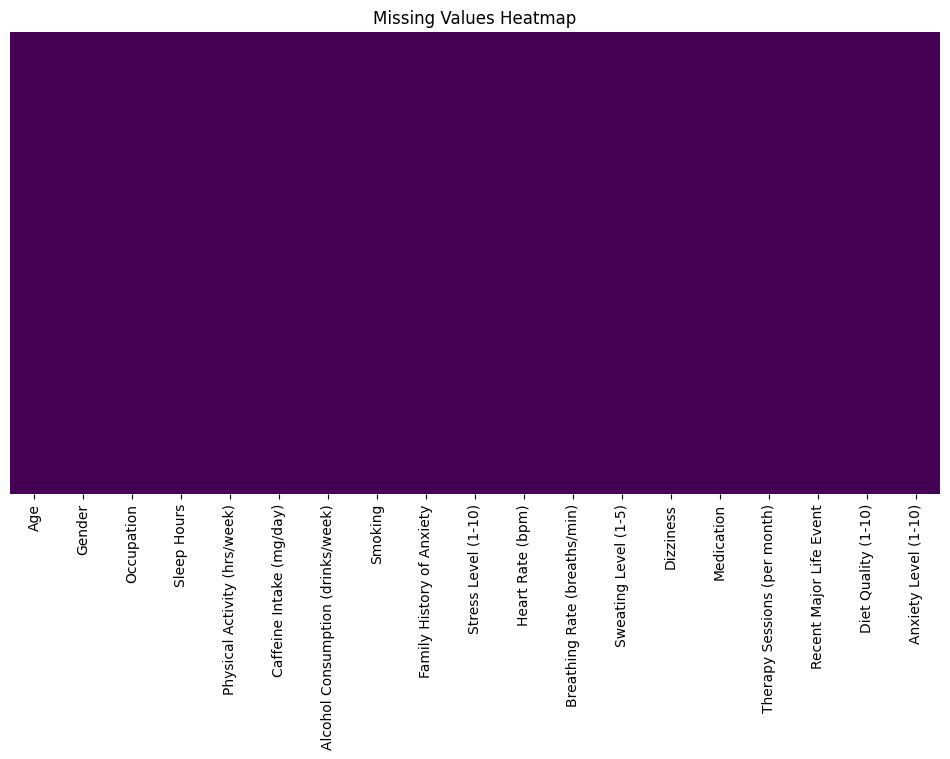

In [6]:
# Missing values summary
missing_data = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data = missing_data.sort_values('Percentage', ascending=False)

print("Missing Value Analysis:")
print(missing_data)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

CORRELATION ANALYSIS

/tmp/ipykernel_24137/2164410188.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Yes': 1, 'No': 0})


Number of numeric columns: 17
Index(['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)', 'Dizziness', 'Medication',
       'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)'],
      dtype='object')


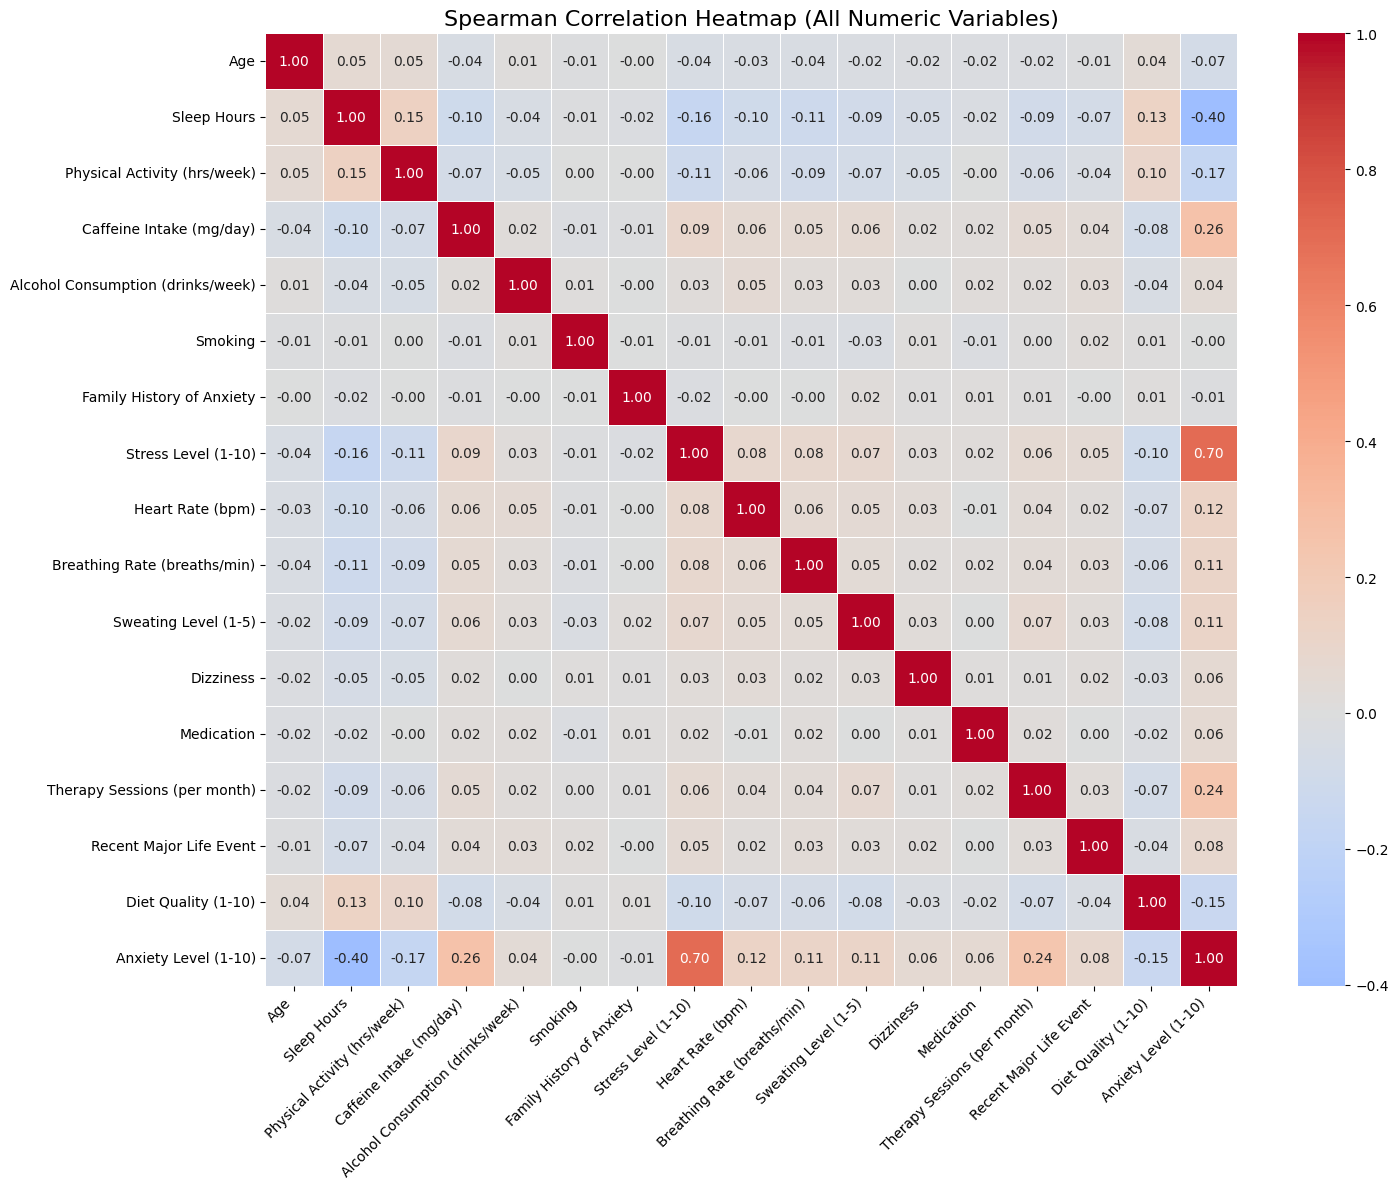

In [7]:

yes_no_cols = [
    'Smoking',
    'Family History of Anxiety',
    'Dizziness',
    'Medication',
    'Recent Major Life Event'
]

data[yes_no_cols] = (
    data[yes_no_cols]
    .replace({'Yes': 1, 'No': 0})
    .infer_objects(copy=False)
)

numeric_data = data.select_dtypes(include=['int64', 'float64'])

print(f"Number of numeric columns: {numeric_data.shape[1]}")
print(numeric_data.columns)

# 4️ Computing Spearman correlation
corr_matrix = numeric_data.corr(method='spearman')

# 5️ Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap (All Numeric Variables)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Highly correlated columns:
['Sleep Hours', 'Stress Level (1-10)', 'Anxiety Level (1-10)']


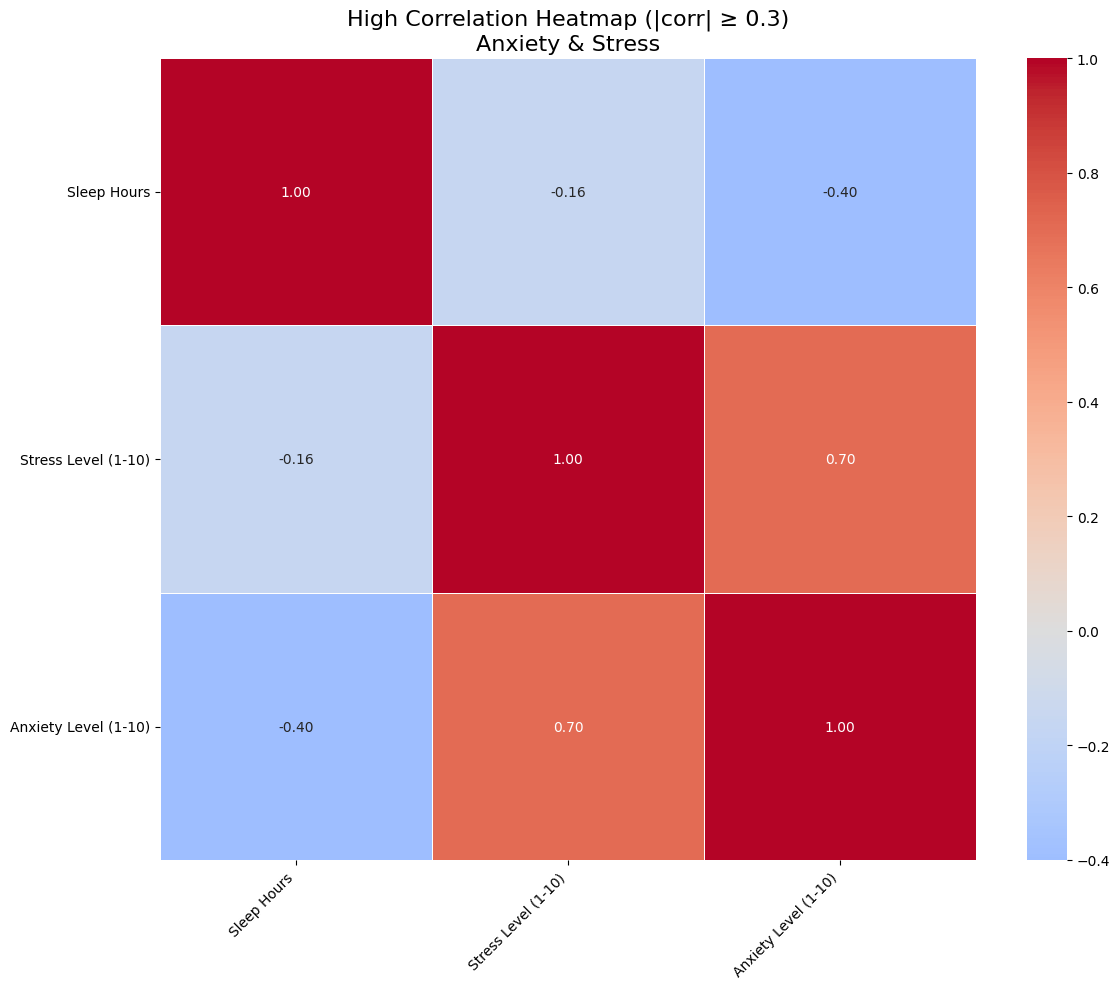

In [8]:
# Select numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute Spearman correlation
corr_matrix = numeric_data.corr(method='spearman')

# Set correlation threshold
threshold = 0.3

# Find columns highly correlated with Anxiety or Stress
target_cols = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

high_corr_cols = corr_matrix[
    target_cols
].abs().max(axis=1)

high_corr_cols = high_corr_cols[high_corr_cols >= threshold].index.tolist()

print("Highly correlated columns:")
print(high_corr_cols)

# Filter correlation matrix
filtered_corr = corr_matrix.loc[high_corr_cols, high_corr_cols]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    f"High Correlation Heatmap (|corr| ≥ {threshold})\nAnxiety & Stress",
    fontsize=16
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Multi-Target Correlation Table:
                                   Anxiety Level (1-10)  Stress Level (1-10)  \
Sleep Hours                                   -0.401197            -0.156943   
Caffeine Intake (mg/day)                       0.256051             0.088739   
Therapy Sessions (per month)                   0.240451             0.056911   
Physical Activity (hrs/week)                  -0.165605            -0.112966   
Diet Quality (1-10)                           -0.149366            -0.098638   
Heart Rate (bpm)                               0.120644             0.081254   
Sweating Level (1-5)                           0.112673             0.073583   
Breathing Rate (breaths/min)                   0.109430             0.084479   
Recent Major Life Event                        0.083324             0.049452   
Age                                           -0.069008            -0.041196   
Dizziness                                      0.056084             0.029247   
Medicati

<Figure size 1200x800 with 0 Axes>

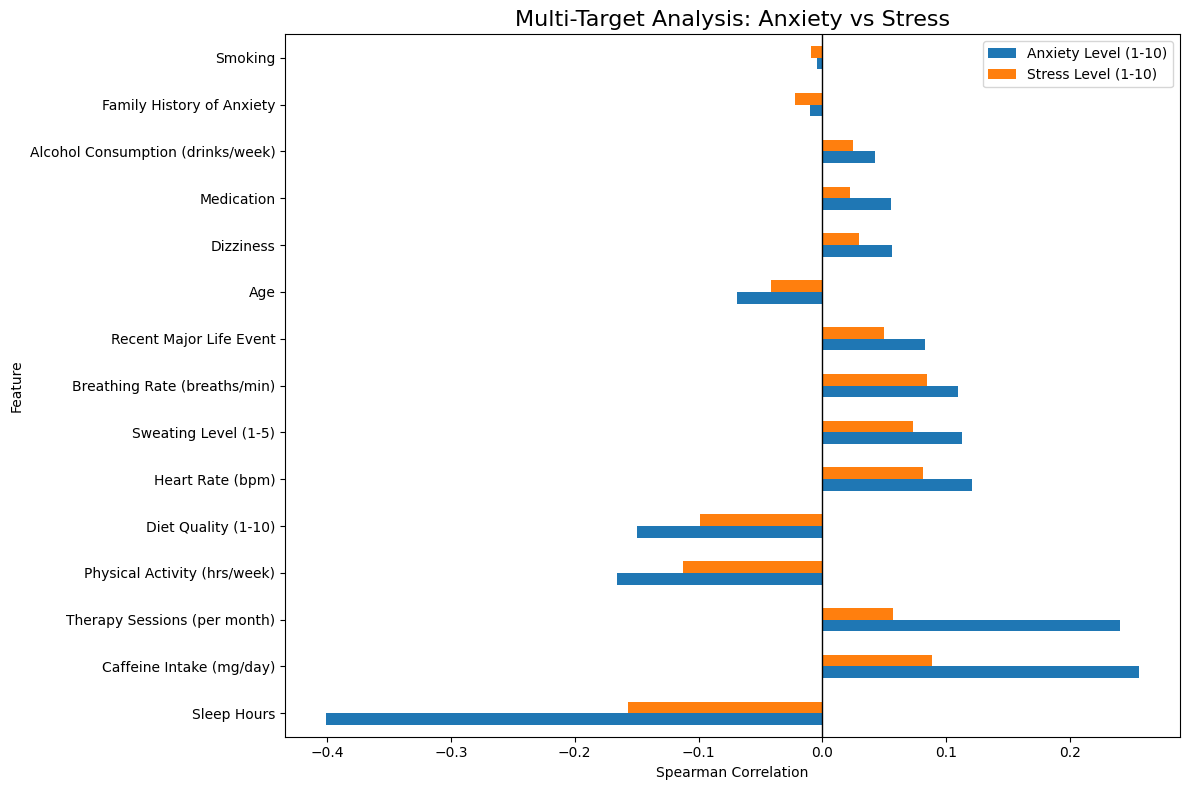

In [9]:

# Define targets
targets = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

# Compute Spearman correlations
target_corr = (
    numeric_data
    .corr(method='spearman')[targets]
    .drop(index=targets)
)

# Sort by maximum absolute correlation
target_corr['Max |Correlation|'] = target_corr.abs().max(axis=1)
target_corr = target_corr.sort_values('Max |Correlation|', ascending=False)

print("Multi-Target Correlation Table:")
print(target_corr)

# Plot grouped bar chart
plt.figure(figsize=(12, 8))
target_corr.drop(columns='Max |Correlation|').plot(
    kind='barh',
    figsize=(12, 8)
)

plt.axvline(0, color='black', linewidth=1)
plt.title("Multi-Target Analysis: Anxiety vs Stress", fontsize=16)
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Target Variable Distribution: Anxiety Level (1-10)


Target Variable Distribution: Anxiety Level (1-10)
count    11000.000000
mean         4.149455
std          2.115930
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         10.000000
Name: Anxiety Level (1-10), dtype: float64



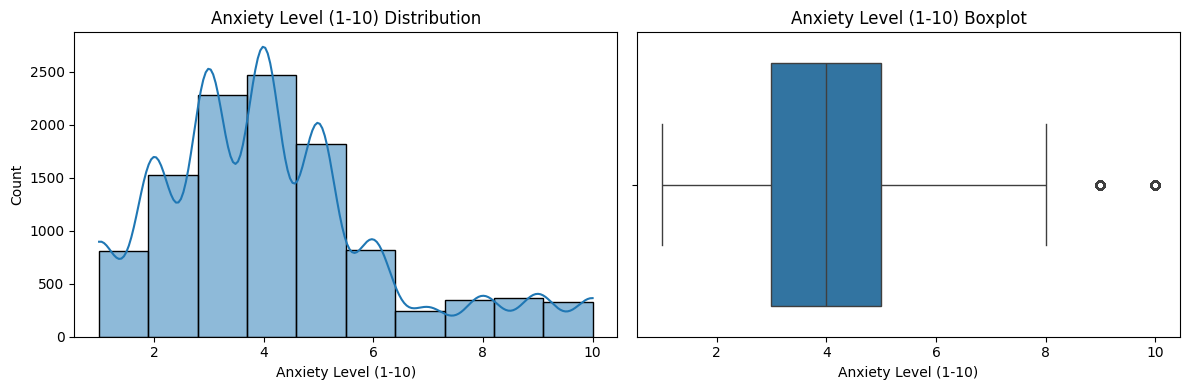


Target Variable Distribution: Stress Level (1-10)
count    11000.000000
mean         5.808545
std          2.941883
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Stress Level (1-10), dtype: float64



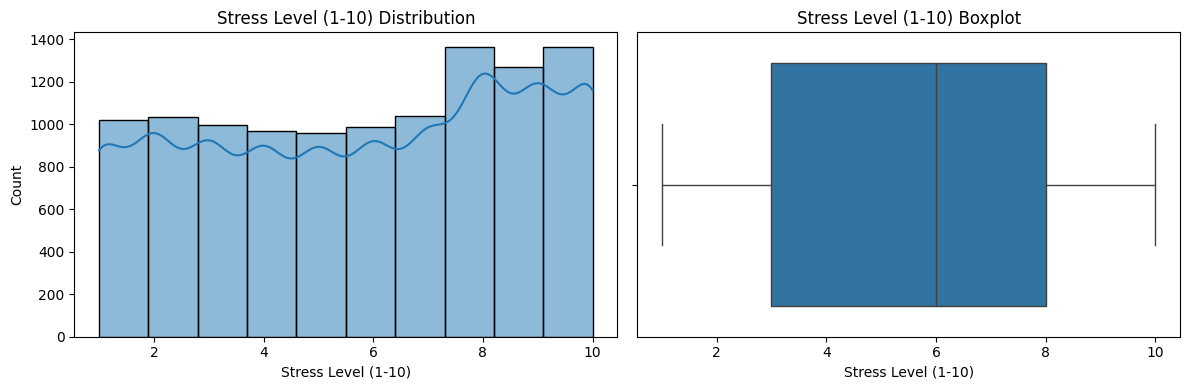

In [10]:
targets = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

for target in targets:
    print(f"\nTarget Variable Distribution: {target}")
    print(data[target].describe())
    print("\n" + "="*60)

    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[target], bins=10, kde=True)
    plt.title(f'{target} Distribution')
    plt.xlabel(target)
    plt.ylabel('Count')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[target])
    plt.title(f'{target} Boxplot')

    plt.tight_layout()
    plt.show()

Number of numerical features: 17
Index(['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)', 'Dizziness', 'Medication',
       'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)'],
      dtype='object')


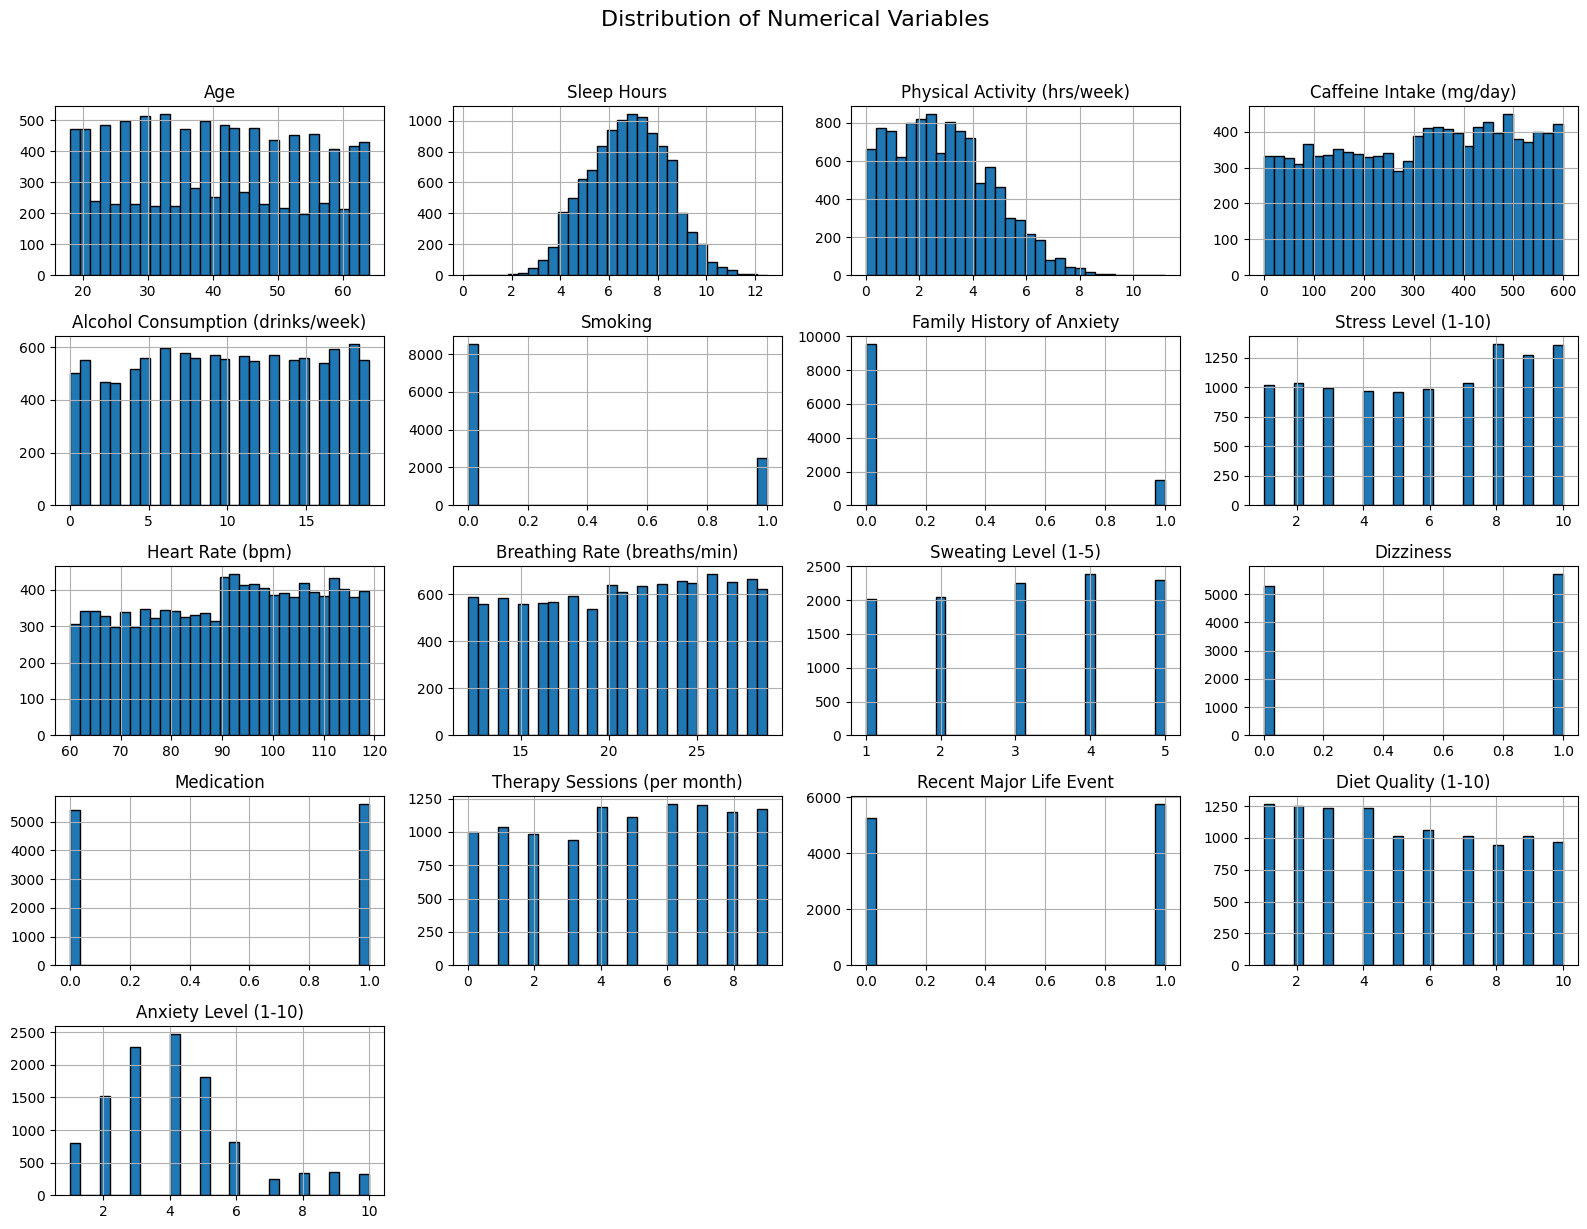

Skewness and Kurtosis Analysis:
                                   Skewness  Kurtosis
Family History of Anxiety          2.154874  2.643963
Smoking                            1.308571 -0.287695
Anxiety Level (1-10)               0.918902  0.662642
Physical Activity (hrs/week)       0.490496 -0.272559
Stress Level (1-10)               -0.148151 -1.273465
Diet Quality (1-10)                0.139806 -1.217157
Heart Rate (bpm)                  -0.128128 -1.157126
Caffeine Intake (mg/day)          -0.115152 -1.186871
Therapy Sessions (per month)      -0.099686 -1.192781
Recent Major Life Event           -0.091380 -1.992012
Breathing Rate (breaths/min)      -0.090613 -1.199353
Sweating Level (1-5)              -0.088569 -1.269781
Dizziness                         -0.071692 -1.995223
Age                                0.061239 -1.156933
Alcohol Consumption (drinks/week) -0.040870 -1.176549
Medication                        -0.035283 -1.999119
Sleep Hours                       -0.011845 -0.262

In [11]:
numerical_cols = data.select_dtypes(include=[np.number]).columns
print(f"Number of numerical features: {len(numerical_cols)}")
print(numerical_cols)

# Histograms for all numerical variables
data[numerical_cols].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black'
)

plt.suptitle(
    'Distribution of Numerical Variables',
    y=1.02,
    fontsize=16
)
plt.tight_layout()
plt.show()

# Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': data[numerical_cols].skew(),
    'Kurtosis': data[numerical_cols].kurtosis()
}).sort_values(by='Skewness', key=abs, ascending=False)

print("Skewness and Kurtosis Analysis:")
print(skew_kurt)
print("\n" + "=" * 60)

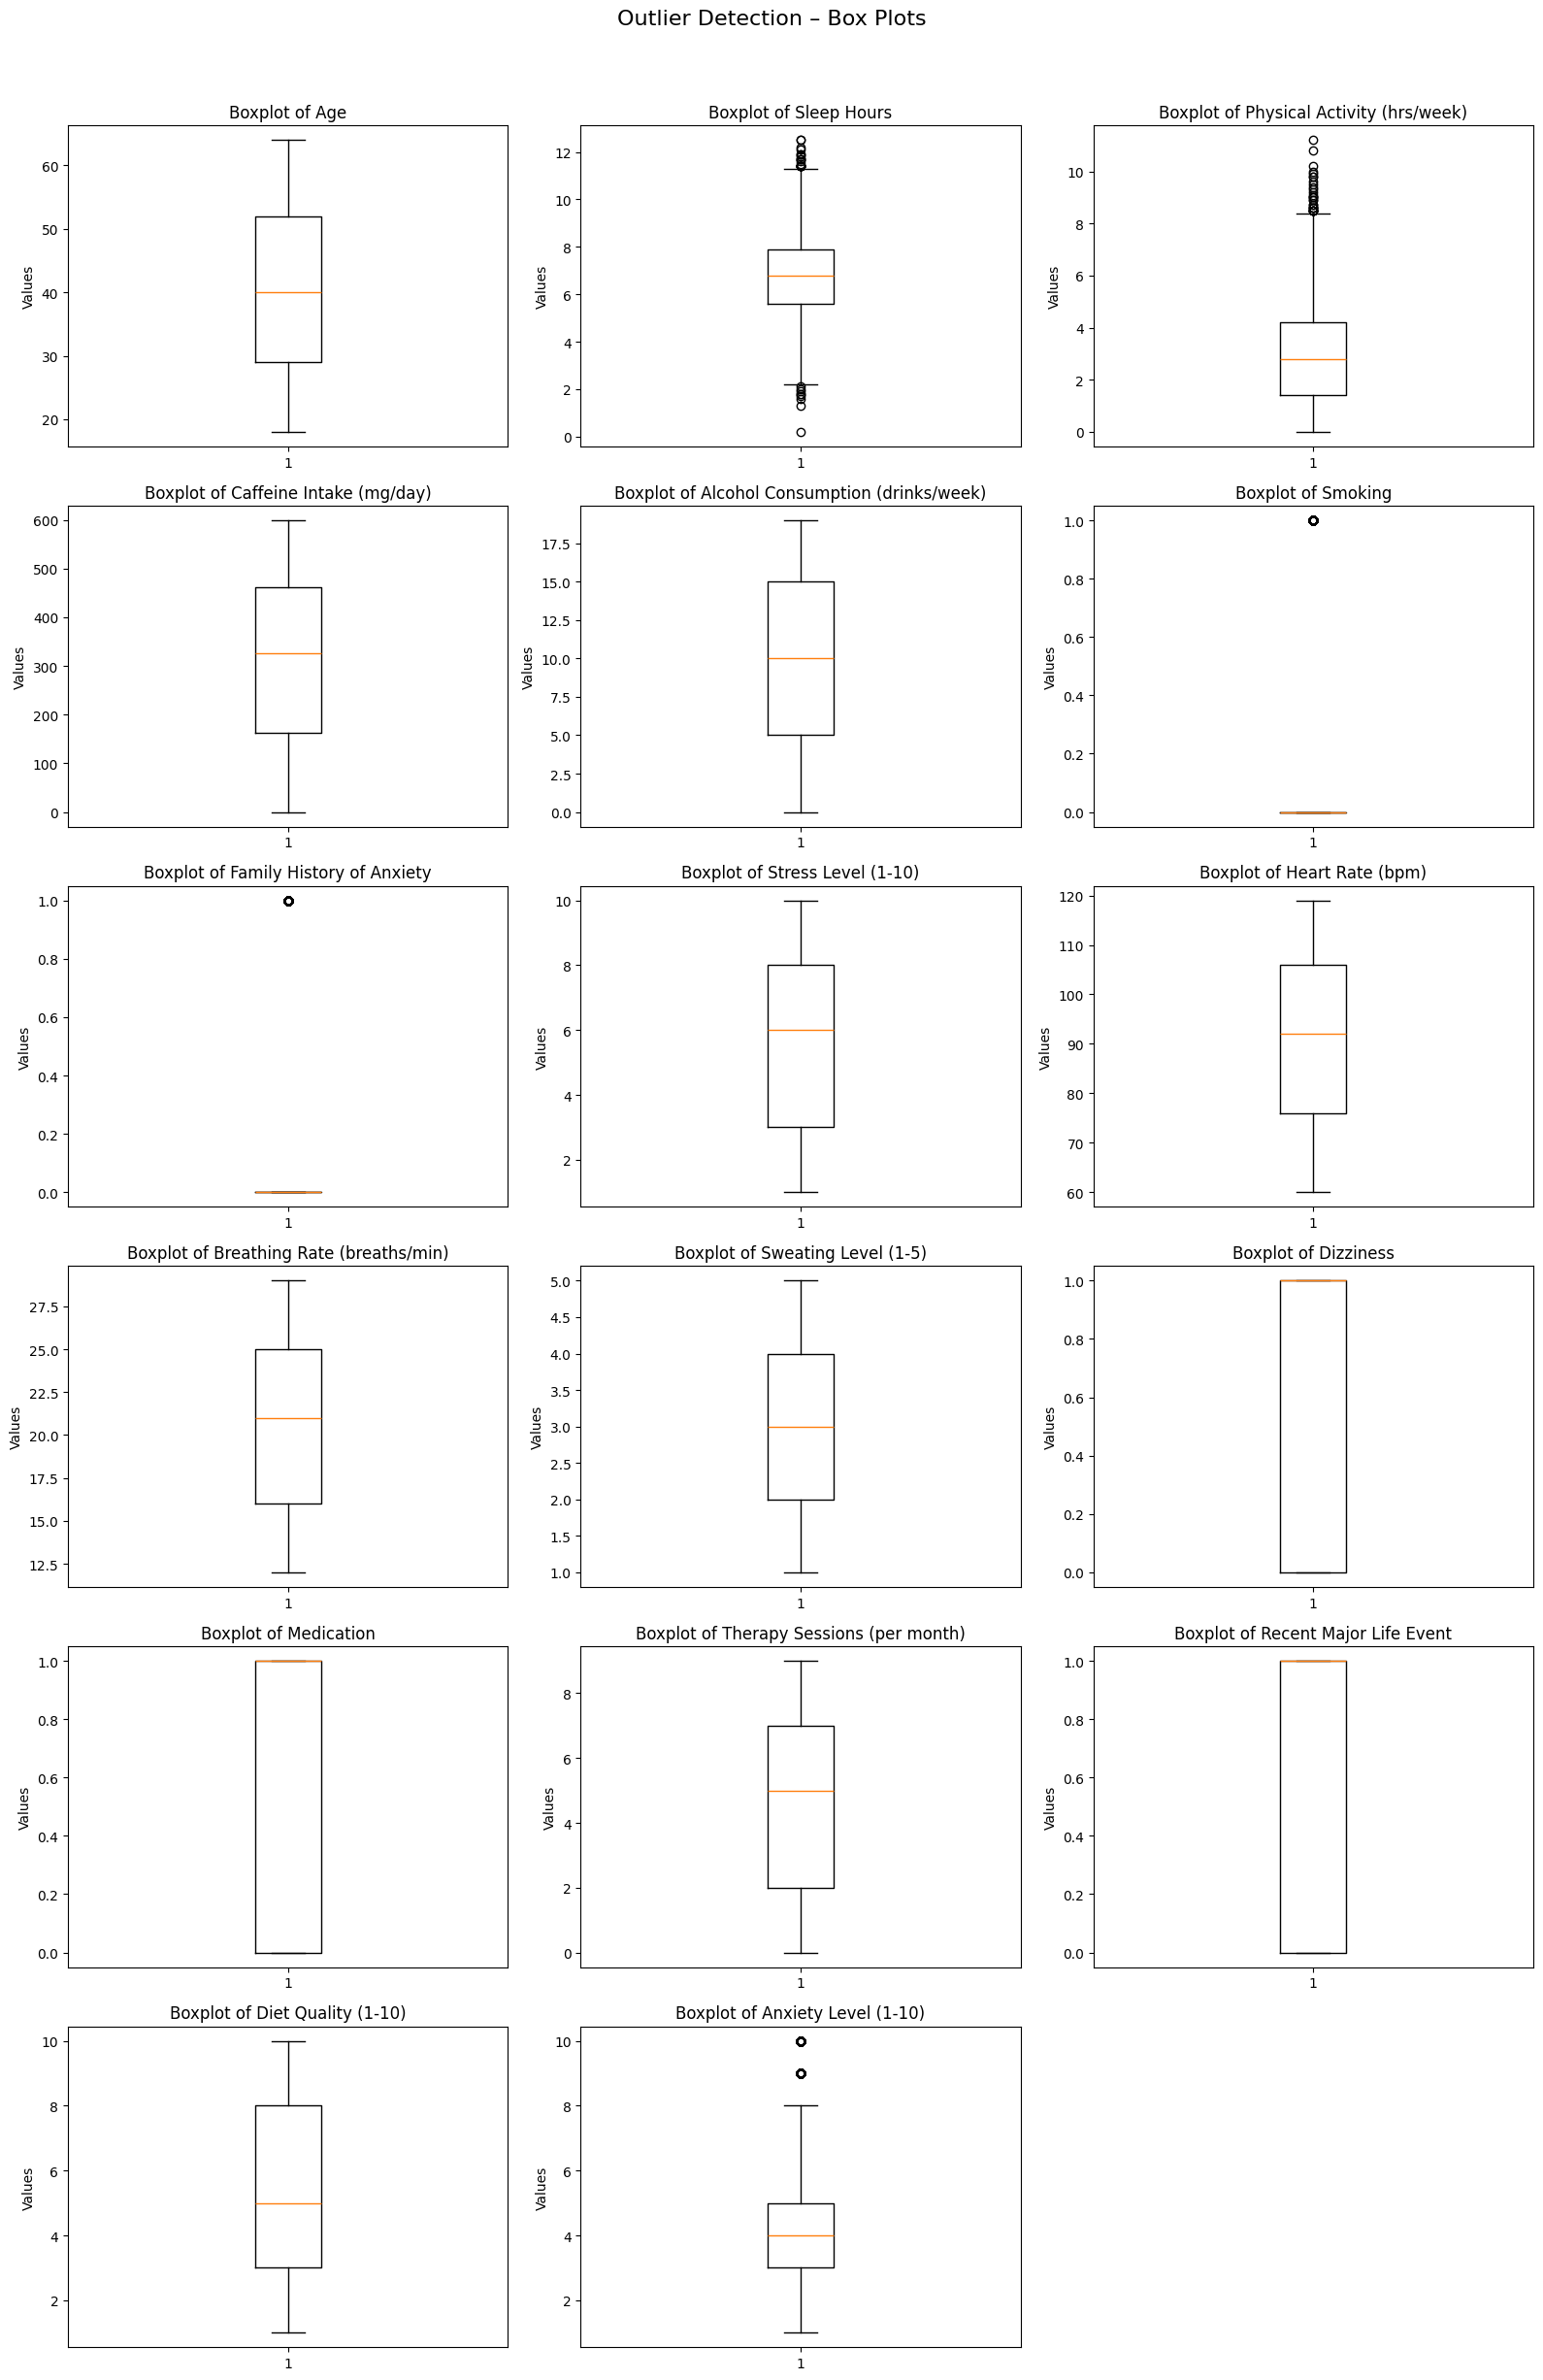

Outlier Summary (IQR Method):
                                   Outlier Count  Outlier Percentage (%)  \
Smoking                                   2489.0               22.627273   
Family History of Anxiety                 1469.0               13.354545   
Anxiety Level (1-10)                       694.0                6.309091   
Physical Activity (hrs/week)                30.0                0.272727   
Sleep Hours                                 28.0                0.254545   
Age                                          0.0                0.000000   
Alcohol Consumption (drinks/week)            0.0                0.000000   
Stress Level (1-10)                          0.0                0.000000   
Caffeine Intake (mg/day)                     0.0                0.000000   
Heart Rate (bpm)                             0.0                0.000000   
Breathing Rate (breaths/min)                 0.0                0.000000   
Dizziness                                    0.0          

In [12]:
# Select numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = len(numerical_cols) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(data[col].dropna())
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel('Values')

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Outlier Detection – Box Plots', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


outliers_summary = {}

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]

    outliers_summary[col] = {
        'Outlier Count': len(outliers),
        'Outlier Percentage (%)': (len(outliers) / len(data)) * 100,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Min Value': data[col].min(),
        'Max Value': data[col].max()
    }

outliers_df = (
    pd.DataFrame(outliers_summary)
    .T
    .sort_values('Outlier Percentage (%)', ascending=False)
)

print("Outlier Summary (IQR Method):")
print(outliers_df)
print("\n" + "=" * 60)

In [13]:

# Step 0: Normalize column names

data.columns = [col.replace('–', '-').strip() for col in data.columns]
print("Normalized Columns:")
print(data.columns.tolist())



# Step 2: Comprehensive Statistical Summary Function

def create_comprehensive_summary(data, target_cols):
    """Generate a detailed statistical summary for numeric, categorical, and targets"""
    
    summary = {}
    
    
    # Dataset Overview
    
    summary['Dataset_Overview'] = {
        'Total_Samples': len(data),
        'Total_Features': len(data.columns),
        'Numerical_Features': len(data.select_dtypes(include=[np.number]).columns),
        'Categorical_Features': len(data.select_dtypes(include=['object', 'category']).columns),
        'Missing_Values_Total': int(data.isnull().sum().sum()),
        'Missing_Values_Percentage': round((data.isnull().sum().sum() / (len(data) * len(data.columns))) * 100, 2)
    }
    
    
    # Target Variable Summary
    
    summary['Targets'] = {}
    for target_col in target_cols:
        summary['Targets'][target_col] = {
            'Type': str(data[target_col].dtype),
            'Missing_Values': int(data[target_col].isnull().sum())
        }
        if data[target_col].dtype in [np.int64, np.float64]:
            summary['Targets'][target_col].update({
                'Mean': data[target_col].mean(),
                'Median': data[target_col].median(),
                'Std': data[target_col].std(),
                'Min': data[target_col].min(),
                'Max': data[target_col].max(),
                'Skewness': data[target_col].skew(),
                'Kurtosis': data[target_col].kurtosis()
            })
        else:
            summary['Targets'][target_col].update({
                'Class_Distribution': dict(data[target_col].value_counts()),
                'Percentage_Distribution': dict((data[target_col].value_counts(normalize=True)*100).round(2))
            })
    
    
    # Numerical Features Summary
    
    numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    summary['Numerical_Features'] = {}
    for col in numerical_cols:
        col_data = data[col].dropna()
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
        
        summary['Numerical_Features'][col] = {
            'Mean': col_data.mean(),
            'Median': col_data.median(),
            'Std': col_data.std(),
            'Min': col_data.min(),
            'Max': col_data.max(),
            'Skewness': col_data.skew(),
            'Kurtosis': col_data.kurtosis(),
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': round(len(outliers)/len(col_data)*100, 2)
        }
    
    
    # Categorical Features Summary
    
    categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
    summary['Categorical_Features'] = {}
    for col in categorical_cols:
        summary['Categorical_Features'][col] = {
            'Unique_Values': data[col].nunique(),
            'Top_Values': dict(data[col].value_counts().head(5))
        }
    
    
    # Data Quality
    
    summary['Data_Quality'] = {
        'Duplicate_Rows': int(data.duplicated().sum()),
        'Constant_Columns': [col for col in data.columns if data[col].nunique() == 1],
        'High_Cardinality_Columns': [col for col in data.columns if data[col].nunique() > 50]
    }
    
    
    # Feature Significance with Targets
    
    summary['Feature_Significance'] = {}
    
    for target in target_cols:
        summary['Feature_Significance'][target] = {'Numerical': [], 'Categorical': []}
        
        # Numerical: Pearson correlation
        for col in numerical_cols:
            if col != target:
                valid_data = data[[col, target]].dropna()
                if len(valid_data) > 2:
                    corr, p_val = stats.pearsonr(valid_data[col], valid_data[target])
                    if p_val < 0.05:
                        summary['Feature_Significance'][target]['Numerical'].append(
                            {'Feature': col, 'Correlation': round(corr,3), 'p-value': round(p_val,4)}
                        )
        
        # Categorical: ANOVA
        for col in categorical_cols:
            valid_data = data[[col, target]].dropna()
            groups = [valid_data[valid_data[col]==cat][target] for cat in valid_data[col].unique()]
            if len(groups) > 1:
                f_stat, p_val = stats.f_oneway(*groups)
                if p_val < 0.05:
                    summary['Feature_Significance'][target]['Categorical'].append(
                        {'Feature': col, 'F-statistic': round(f_stat,3), 'p-value': round(p_val,4)}
                    )
    
    return summary


# Step 3: Generate report for Stress and Anxiety

summary_report = create_comprehensive_summary(
    data, 
    target_cols=['Stress Level (1-10)', 'Anxiety Level (1-10)']
)


# Step 4: Print summary neatly

print("COMPREHENSIVE STATISTICAL REPORT")
print("="*80)

for section, content in summary_report.items():
    print(f"\n{section.replace('_',' ').title()}:")
    print("-"*60)
    if isinstance(content, dict):
        for key, value in content.items():
            print(f"\n{key}:")
            if isinstance(value, dict):
                for subkey, subval in value.items():
                    print(f"  {subkey}: {subval}")
            else:
                print(f"  {value}")
    else:
        print(content)


Normalized Columns:
['Age', 'Gender', 'Occupation', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event', 'Diet Quality (1-10)', 'Anxiety Level (1-10)']
COMPREHENSIVE STATISTICAL REPORT

Dataset Overview:
------------------------------------------------------------

Total_Samples:
  11000

Total_Features:
  19

Numerical_Features:
  17

Categorical_Features:
  2

Missing_Values_Total:
  0

Missing_Values_Percentage:
  0.0

Targets:
------------------------------------------------------------

Stress Level (1-10):
  Type: int64
  Missing_Values: 0
  Mean: 5.808545454545454
  Median: 6.0
  Std: 2.941883308430984
  Min: 1
  Max: 10
  Skewness: -0.14815084915293597
  Kurtosis: -1.273465165807815

Anxiety Level (

In [14]:
data.to_csv("clean2.csv", index=False)
# data.to_csv("clean.csv", index=False)
print("CSV file successfully saved")


CSV file successfully saved
